In [1]:
import numpy as np
import pandas as pd
import sys
sys.path.append('..')
from gstatsmcmc import Topography, MCMC
import gstatsim as gs
from sklearn.preprocessing import QuantileTransformer
import skgstat as skg
import config

# data viz
import matplotlib.pyplot as plt
from matplotlib.colors import LightSource, Normalize
from matplotlib.patches import Patch
from matplotlib import cm
from scipy.ndimage import gaussian_filter, binary_erosion
import numpy as np
import os 

In [2]:
## Load our data 

df = pd.read_csv('./BindSchalder_Macayeal_IceStreams.csv')

# create a grid of x and y coordinates
x_uniq = np.unique(df.x)
y_uniq = np.unique(df.y)

xmin = np.min(x_uniq)
xmax = np.max(x_uniq)
ymin = np.min(y_uniq)
ymax = np.max(y_uniq)

cols = len(x_uniq)
rows = len(y_uniq)

resolution = 500

xx, yy = np.meshgrid(x_uniq, y_uniq)

# load other data
dhdt = df['dhdt'].values.reshape(xx.shape)
smb = df['smb'].values.reshape(xx.shape)
velx = df['velx'].values.reshape(xx.shape)
vely = df['vely'].values.reshape(xx.shape)
bedmap_mask = df['bedmap_mask'].values.reshape(xx.shape)
bedmachine_thickness = df['bedmachine_thickness'].values.reshape(xx.shape)
bedmap_surf = df['bedmap_surf'].values.reshape(xx.shape)
highvel_mask = df['highvel_mask'].values.reshape(xx.shape)
bedmap_bed = df['bedmap_bed'].values.reshape(xx.shape)

# create conditioning data
# bed elevation measurement in grounded ice region, and bedmachine bed topography elsewhere
cond_bed = np.where(bedmap_mask == 1, df['bed'].values.reshape(xx.shape), bedmap_bed)
df['cond_bed'] = cond_bed.flatten()

# create a mask of conditioning data
data_mask = ~np.isnan(cond_bed)

# normalize the conditioning bed data, saved to df['Nbed']
data = df['cond_bed'].values.reshape(-1,1)
nst_trans = QuantileTransformer(n_quantiles=500, output_distribution="normal",random_state=0).fit(data)
transformed_data = nst_trans.transform(data)
df['Nbed'] = transformed_data


In [3]:
# Load our previous bed 
INITIAL_BED = np.loadtxt(f'sgs_bed_bindshalder.txt')    
NUMBER_OF_ITERATIONS = 350000
index_we_want_compare = 274
last_iterated_bed = np.loadtxt(f'./SGS_realizations/{index_we_want_compare}final_bed_largeCRF.txt')    


print(index_we_want_compare)


274


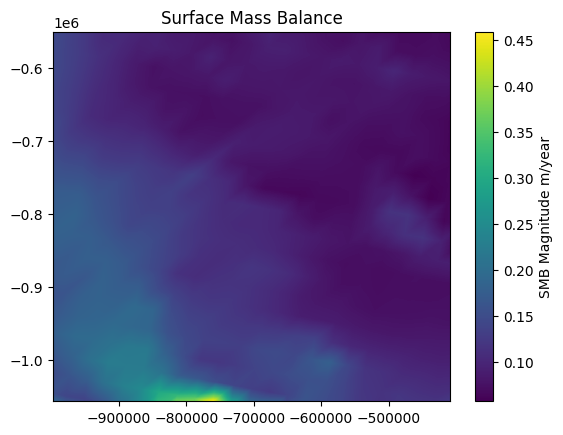

In [23]:
ims = plt.pcolormesh(xx,yy, smb)
cbar = plt.colorbar(ims)
cbar.set_label("SMB Magnitude m/year")
plt.title("Surface Mass Balance")
plt.savefig("smb.png", dpi=500, bbox_inches='tight')


Text(0.5, 1.0, 'BedMachine')

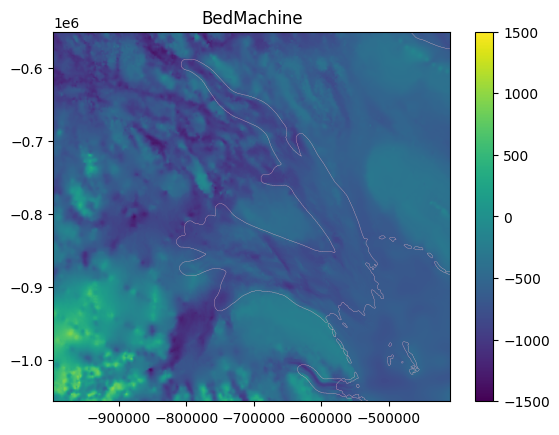

In [18]:
plt.pcolormesh(xx,yy,bedmap_surf- bedmachine_thickness, vmin = -1500, vmax = 1500)
plt.colorbar()
plt.contour(xx, yy, highvel_mask, levels=[0.2], colors='pink', linewidths=0.2)
plt.savefig("1bedmachine.png", dpi=500, bbox_inches='tight')

plt.title("BedMachine")

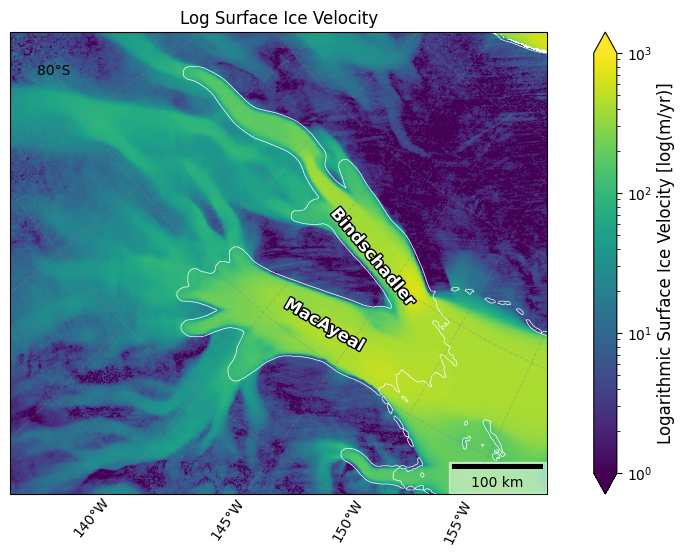

In [191]:
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.patheffects as pe  # <--- Import this explicitly
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from matplotlib_scalebar.scalebar import ScaleBar

# 1. Calculate Velocity Magnitude (Speed)
speed = np.sqrt(velx**2 + vely**2)

# 2. Setup Figure with Antarctic Projection
projection = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(figsize=(12, 6), subplot_kw={'projection': projection})

# 3. Plot Surface Velocity Magnitude
im = ax.pcolormesh(xx, yy, speed, 
                   cmap='viridis', 
                   norm=colors.LogNorm(vmin=1, vmax=1000), 
                   shading='auto', 
                   transform=projection)
n = 8  # Adjust this: Higher = fewer arrows, faster rendering

# 5. Outline the Ice Streams
ax.contour(xx, yy, highvel_mask, levels=[0.5], colors='white', linewidths=0.5, transform=projection)

# 6. Add Text Labels with Path Effects (Outlines)
ax.text(-650000, -850000, "Bindschadler", transform=projection,
        color='white', fontsize=12, fontweight='bold', rotation=-50,
        path_effects=[pe.withStroke(linewidth=2, foreground="black")])

ax.text(-700000, -900000, "MacAyeal", transform=projection,
        color='white', fontsize=12, fontweight='bold', rotation=-30,
        path_effects=[pe.withStroke(linewidth=2, foreground="black")])

# 7. Add Colorbar
cbar = fig.colorbar(im, ax=ax, extend='both')
cbar.set_label('Logarithmic Surface Ice Velocity [log(m/yr)]', fontsize=12)

# 8. Add Gridlines and Scale Bar
gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.3, color='gray')
gl.top_labels = False
gl.right_labels = False

scalebar = ScaleBar(1, "m", length_fraction=0.2, location='lower right', box_alpha=0.5)
ax.add_artist(scalebar)

ax.set_title("Log Surface Ice Velocity")
plt.savefig("velocityplot.png", dpi=500, bbox_inches='tight')


plt.show()

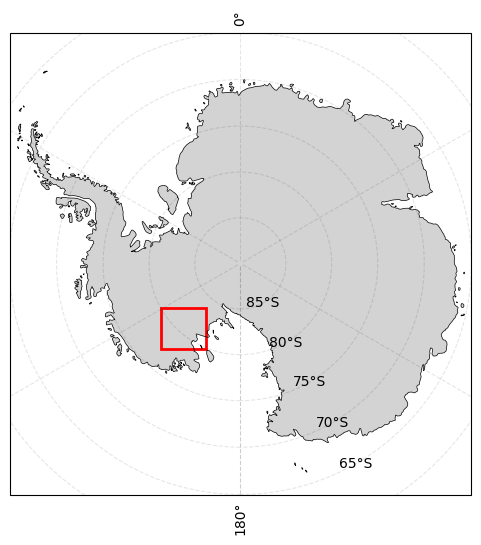

In [148]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# 1. Setup the Map Projection (Antarctic Polar Stereographic)
fig = plt.figure(figsize=(6, 6))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

# 2. Add Geographic Features (The "Grounding Lines" context)

ax.add_feature(cfeature.LAND, facecolor='lightgrey')
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.gridlines(draw_labels=True, color='black', alpha=0.1, linestyle='--')

# 3. Define Your Study Area Bounds (Inferred from your first image)
# Coordinates are in meters (EPSG:3031)
x_min, x_max = -980000, -420000
y_min, y_max = -1050000, -550000

# 4. Create the Bounding Box
study_box = mpatches.Rectangle(
    (x_min, y_min),          # Bottom-left corner (x, y)
    width=x_max - x_min,     # Width
    height=y_max - y_min,    # Height
    facecolor='none',        # Transparent fill
    edgecolor='red',         # Red border
    linewidth=2,             # Thicker line for visibility
    transform=ccrs.SouthPolarStereo() # Ensure it maps correctly
)
ax.add_patch(study_box)

# 5. Set the Camera/Extent to show the full continent or just West Antarctica
ax.set_extent([-180, 180, -90, -65], ccrs.PlateCarree())

plt.savefig("study_area.png", dpi=500, bbox_inches='tight')

plt.show()

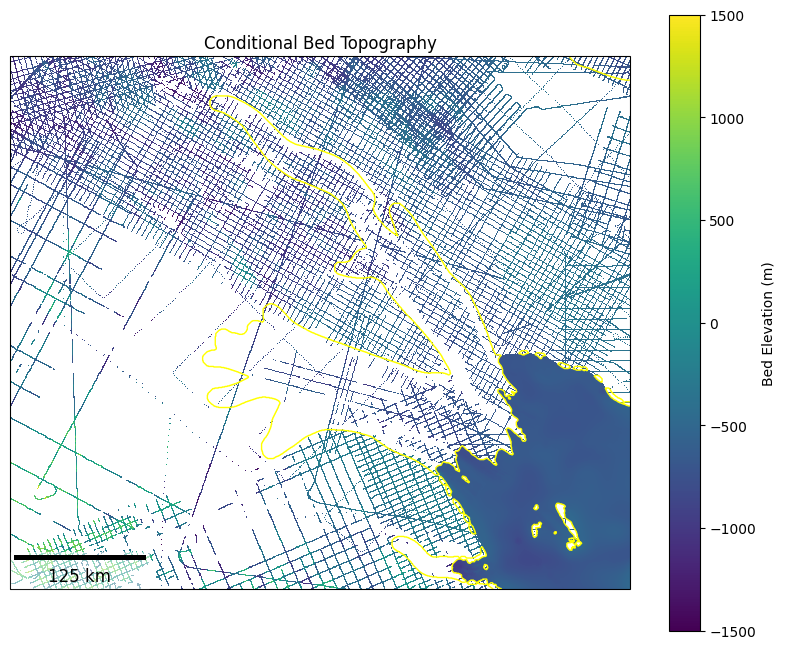

In [159]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib_scalebar.scalebar import ScaleBar

# 1. Setup Main Figure with the specific Projection
projection = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': projection})

# 2. Main Plot 
ims = ax.pcolormesh(xx, yy, cond_bed, shading='auto', transform=projection, vmin = -1500, vmax = 1500)

fig.colorbar(ims, ax=ax, label="Bed Elevation (m)")
ax.set_title("Conditional Bed Topography")
plt.contour(xx, yy, highvel_mask, levels=[0.5], colors='yellow', linewidths=1)



# 4. Add Scale Bar
# dx=1 means "1 pixel/unit = 1 meter"
scalebar = ScaleBar(1, "m", 
                    length_fraction=0.25,     # Bar length = 25% of plot width
                    location='lower left',   # Placement
                    box_alpha=0.5,            # Semi-transparent background
                    font_properties={'size': 12}) # Make text readable
ax.add_artist(scalebar)

plt.savefig("cond_bed_with_scale.png", dpi=500, bbox_inches='tight')
plt.show()

Plotted initial bed


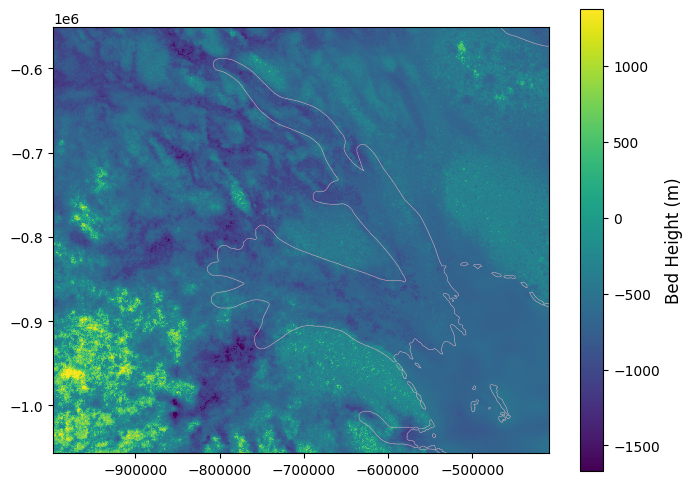

In [117]:
plt.figure(figsize=(8, 6)) # Adjust size as needed
im1 = plt.pcolormesh(xx, yy, sgs_bed, cmap='viridis')
plt.axis('scaled')

# Colorbar
cbar1 = plt.colorbar(im1)
cbar1.set_label('Bed Height (m)', fontsize=12)

# Contour mask
plt.contour(xx, yy, highvel_mask, levels=[0.5], colors='pink', linewidths=0.3)

#plt.title("Initial Bed (SGS)", fontsize=14)
plt.savefig("1_initial_bed.png", dpi=150, bbox_inches='tight')
print("Plotted initial bed")
plt.show()
plt.close()

Plotted bedmachine vs mcmc difference


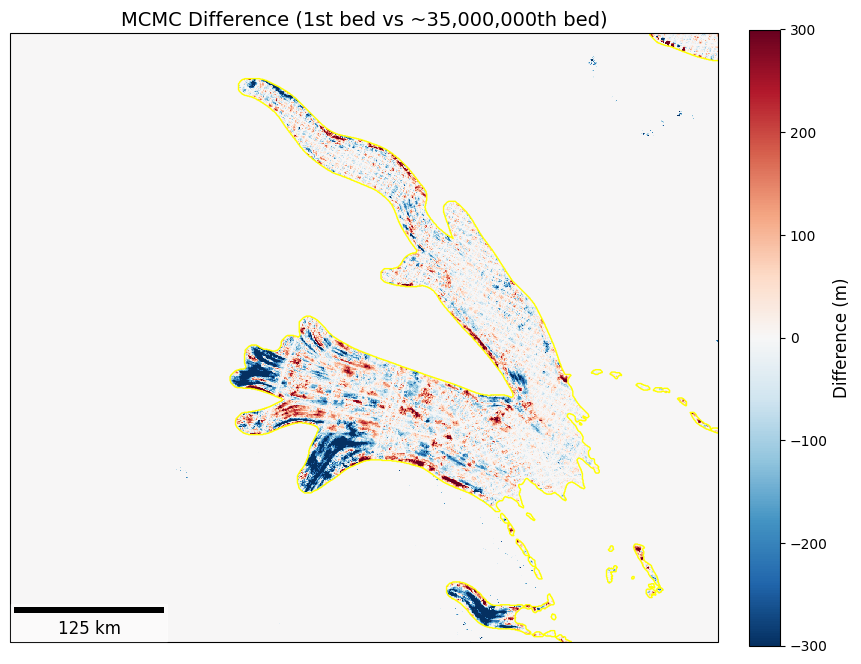

In [196]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
from matplotlib_scalebar.scalebar import ScaleBar

# 1. Calculate Difference
difference = (last_iterated_bed - INITIAL_BED)

# 2. Setup Figure with Projection
projection = ccrs.SouthPolarStereo()
fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': projection})

# 3. Plot Difference Map
# Note: We use ax.pcolormesh and pass 'transform=projection'
im3 = ax.pcolormesh(xx, yy, difference, cmap='RdBu_r', 
                    vmax=300, vmin=-300, transform=projection)

# 4. Overlay Contour (High Velocity Mask)
ax.contour(xx, yy, highvel_mask, levels=[0.5], 
           colors='yellow', linewidths=1.0, transform=projection)
"""
# 5. Add Gridlines
gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                  linewidth=1, color='gray', alpha=0.2, linestyle='--')
gl.top_labels = False       
gl.right_labels = False     
gl.xlabel_style = {'size': 10, 'color': 'gray'}
gl.ylabel_style = {'size': 10, 'color': 'gray'}
"""
# 6. Add Scale Bar
scalebar = ScaleBar(1, "m", 
                    length_fraction=0.25,     
                    location='lower left',    
                    box_alpha=0.5,            
                    font_properties={'size': 12}) 
ax.add_artist(scalebar)

# 7. Colorbar and Titles
cbar3 = fig.colorbar(im3, ax=ax, fraction=0.046, pad=0.04)
cbar3.set_label('Difference (m)', fontsize=12)

ax.set_title(f"MCMC Difference (1st bed vs ~35,000,000th bed)", fontsize=14)

plt.savefig("3_difference_map.png", dpi=150, bbox_inches='tight')
print("Plotted bedmachine vs mcmc difference")
plt.show()
plt.close()

Plotted MCMC topography


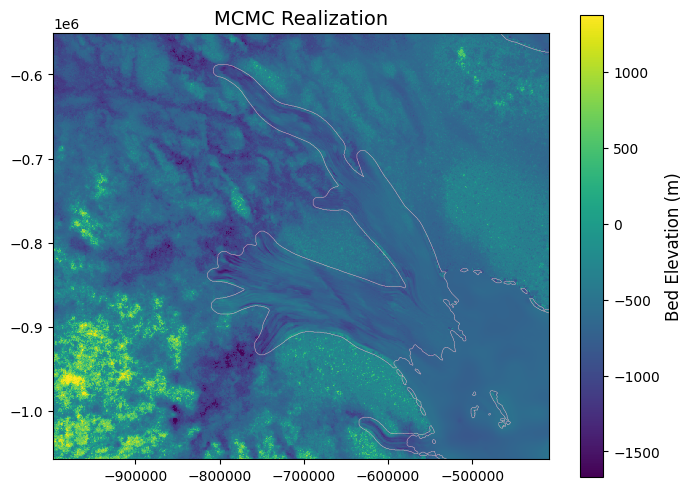

In [116]:
bed_small = np.loadtxt("./T4-1/T4_bed17.txt")
plt.figure(figsize=(8, 6))
# Using current_beds = last_iterated_bed from your snippet
im2 = plt.pcolormesh(xx, yy, bed_small, cmap='viridis')
plt.axis('scaled')

# Colorbar
cbar2 = plt.colorbar(im2)
cbar2.set_label('Bed Elevation (m)', fontsize=12)

# Contour mask
plt.contour(xx, yy, highvel_mask, levels=[0.5], colors='pink', linewidths=0.3)

plt.title("MCMC Realization", fontsize=14)
plt.savefig("2_mcmc_realization.png", dpi=150, bbox_inches='tight')
print("Plotted MCMC topography")
plt.show()
plt.close()

In [12]:
all_losses = []
base_path = './SGS_realizations/'
output_filename = '1combined_losses.txt'
print("Loading and concatenating files...")

for i in range(10,275):
    filename = f'{base_path}{i}_loss_largeCRF.txt'
    
    if os.path.exists(filename):
        try:
            loss_data = np.loadtxt(filename, ndmin=1)
            all_losses.append(loss_data)
        except Exception as e:
            print(f"Could not load {filename}: {e}")
    else:
        print(f"File not found, skipping: {filename}")
        
if all_losses:
    # 1. Concatenate the list of arrays into one long array
    combined_losses = np.concatenate(all_losses)
    
    # 2. SAVE the data (Use np.savetxt, not np.loadtxt)
    np.savetxt(output_filename, combined_losses)
    
    print(f"Success! Saved {len(combined_losses)} loss values to '{output_filename}'")
else:
    print("No files were loaded, nothing to save.")

Loading and concatenating files...
Success! Saved 35920000 loss values to '1combined_losses.txt'


In [84]:
small_loss_chain1 = np.loadtxt('T4_1_combined_losses.txt')
small_loss_chain2 = np.loadtxt('T4_2_combined_losses.txt')

large_loss_chain = np.loadtxt('1combined_losses.txt')
full_loss_chain = np.concatenate((large_loss_chain, small_loss_chain))
print("Combined shape of: ", full_loss_chain.shape)
large_loss_chain.shape , small_loss_chain.shape

Combined shape of:  (36450000,)


((35920000,), (530000,))

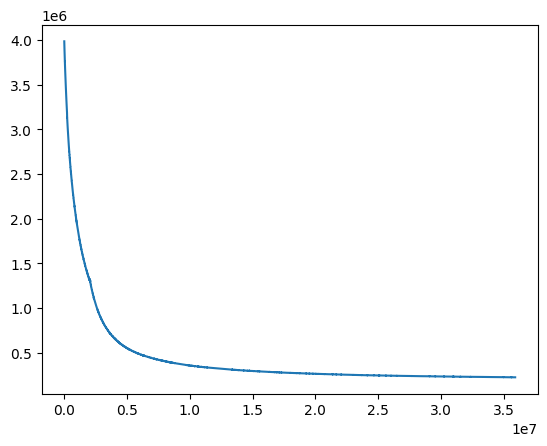

In [87]:
plt.plot(large_loss_chain)


225980.0

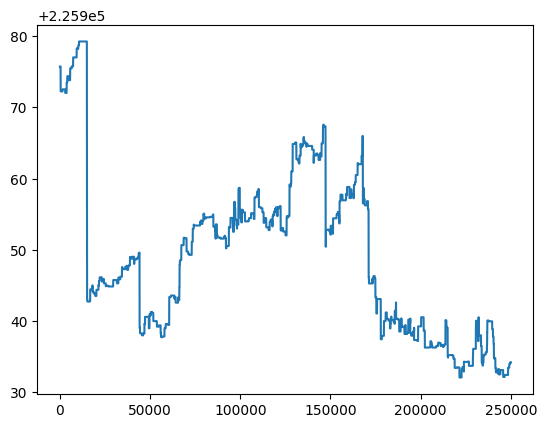

In [85]:
plt.plot(small_loss_chain2)
80 + 2.259e5

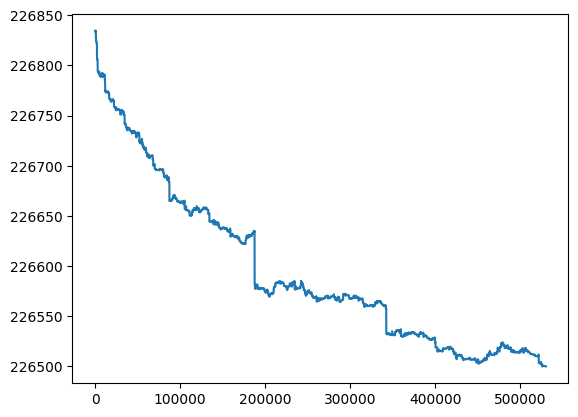

In [86]:
plt.plot(small_loss_chain1)

Plotted multi-chain loss


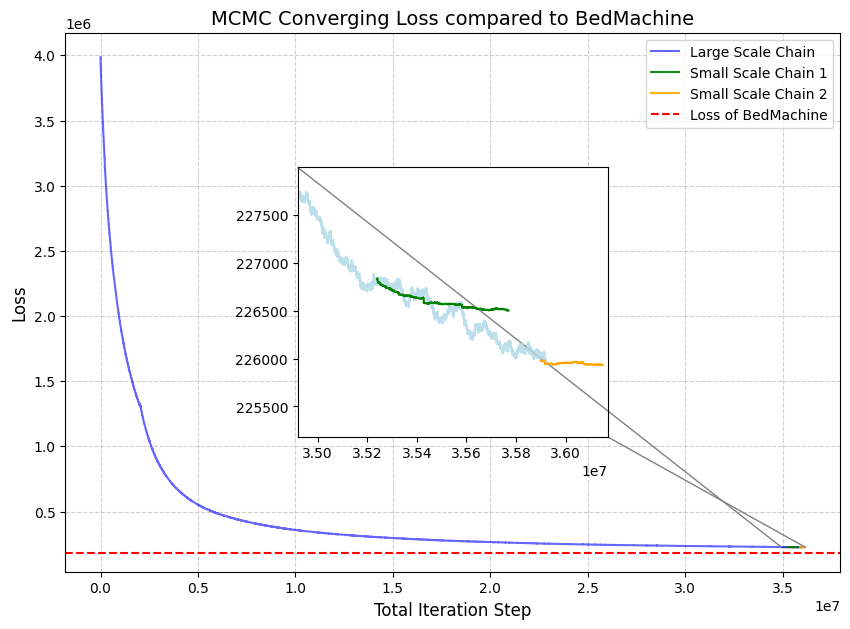

In [96]:
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Loss exist, then plot
if len(large_loss_chain) > 0 and len(small_loss_chain1) > 0 and len(small_loss_chain2) > 0:    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # --- 1. SETUP X-AXIS RANGES ---
    # Define how far back from the end of the large chain each small chain starts
    # offset 1: starts 300k steps before large chain ends
    # offset 2: starts 100k steps before large chain ends (or separate tail)
    offset1 = 680000 
    offset2 = 20000 

    # Calculate absolute start indices
    start_idx_1 = max(0, len(large_loss_chain) - offset1)
    start_idx_2 = max(0, len(large_loss_chain) - offset2)

    # Create X arrays
    x_large  = np.arange(0, len(large_loss_chain))
    x_small1 = np.arange(start_idx_1, start_idx_1 + len(small_loss_chain1))
    x_small2 = np.arange(start_idx_2, start_idx_2 + len(small_loss_chain2))

    # --- 2. MAIN PLOT ---
    # Plot Large Chain
    ax.plot(x_large, large_loss_chain, label='Large Scale Chain', c='blue', alpha=0.6)    
    
    # Plot Small Chain 1
    ax.plot(x_small1, small_loss_chain1, label='Small Scale Chain 1', c='green', alpha=0.9)

    # Plot Small Chain 2
    ax.plot(x_small2, small_loss_chain2, label='Small Scale Chain 2', c='orange', alpha=0.9)
    
    # BedMachine Loss Reference Line
    ax.axhline(182270.73586298342, ls='--', c='red', label='Loss of BedMachine')

    # Formatting
    ax.set_xlabel("Total Iteration Step", fontsize=12)
    ax.set_ylabel("Loss", fontsize=12)
    ax.set_title("MCMC Converging Loss compared to BedMachine", fontsize=14)
    ax.legend(loc='upper right') 
    ax.grid(True, linestyle='--', alpha=0.6)
    
    # --- 3. ZOOM INSET ---
    # Define the viewing window (X-axis) for the zoom
    # We center the zoom around the end of the large chain
    zoom_center = len(large_loss_chain)
    window_radius = 500000 
    
    x_min_zoom = zoom_center - window_radius*2
    x_max_zoom = zoom_center + window_radius/2

    # Create Inset Axes
    axins = inset_axes(ax, width="40%", height="50%", loc='center')

    # Plot data on Inset
    axins.plot(x_large, large_loss_chain, c='lightblue', alpha=0.8)
    axins.plot(x_small1, small_loss_chain1, c='green')
    axins.plot(x_small2, small_loss_chain2, c='orange')
    axins.axhline(182270.73, ls='--', c='red')
    
    # --- 4. DYNAMIC Y-LIMITS FOR ZOOM ---
    # We need to find the min/max Y values ONLY for data visible in the zoom window
    # This prevents the zoom box from being squished if there is a huge spike elsewhere
    
    # Helper to filter data within x_min/x_max
    def get_local_data(x_arr, y_arr, x_min, x_max):
        mask = (x_arr >= x_min) & (x_arr <= x_max)
        return y_arr[mask] if mask.any() else np.array([])

    local_l = get_local_data(x_large, np.array(large_loss_chain), x_min_zoom, x_max_zoom)
    local_s1 = get_local_data(x_small1, np.array(small_loss_chain1), x_min_zoom, x_max_zoom)
    local_s2 = get_local_data(x_small2, np.array(small_loss_chain2), x_min_zoom, x_max_zoom)
    
    # Concatenate all visible data to find min/max
    all_local_data = np.concatenate([local_l, local_s1, local_s2])
    
    if len(all_local_data) > 0:
        y_min_zoom = np.min(all_local_data) - 750 # Add buffer
        y_max_zoom = np.max(all_local_data) + 250
        axins.set_ylim(y_min_zoom, y_max_zoom)

    # Set X Limits for Zoom
    axins.set_xlim(x_min_zoom, x_max_zoom)
    
    # Turn off grid for cleanliness in zoom
    axins.grid(False)
    
    # Draw the connector lines
    mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")
    
    plt.savefig("4_loss_metric_multi.png", dpi=150, bbox_inches='tight')
    print("Plotted multi-chain loss")
    plt.show()
    plt.close()

In [ ]:
plt.pcolormesh(xx, yy, cond_bed)
plt.contour(xx, yy, highvel_mask, colors='yellow', linewidths=2.0)
plt.axis('scaled')
plt.title("Radar Measurement with High Velocity Region", fontsize=14)
plt.savefig("5_radar_measurement.png", dpi=150, bbox_inches='tight')
print("Plotted Radar Measurements")
plt.show()
plt.close()

In [110]:
bed_small = np.loadtxt("./T4-2/T4_bed4.txt")
plt.figure(figsize=(8, 6)) # Adjust size as needed
im1 = plt.pcolormesh(xx, yy, bed_small, cmap='viridis')
plt.axis('scaled')

# Colorbar
cbar1 = plt.colorbar(im1)
cbar1.set_label('Bed Height (m)', fontsize=12)

# Contour mask
plt.contour(xx, yy, highvel_mask, levels=[0.5], colors='pink', linewidths=1.0)

plt.title("Initial Bed (SGS)", fontsize=14)
plt.savefig("Ending_bed.png", dpi=150, bbox_inches='tight')
print("Plotted initial bed")
plt.show()
plt.close()

FileNotFoundError: ./T4-2/T4_bed4.txt not found.

Plotted initial bed


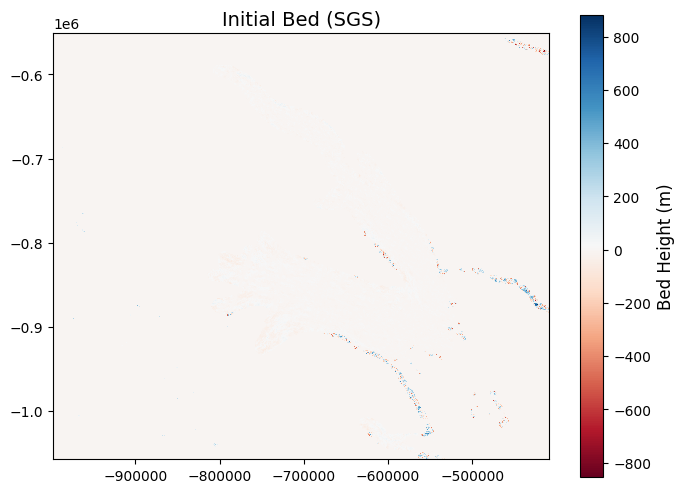

In [109]:
plt.figure(figsize=(8, 6)) # Adjust size as needed
im1 = plt.pcolormesh(xx, yy, last_iterated_bed - bed_small, cmap='RdBu')
plt.axis('scaled')

# Colorbar
cbar1 = plt.colorbar(im1)
cbar1.set_label('Bed Height (m)', fontsize=12)

# Contour mask
#plt.contour(xx, yy, highvel_mask, levels=[0.5], colors='pink', linewidths=1.0)

plt.title("Initial Bed (SGS)", fontsize=14)
print("Plotted initial bed")
plt.show()
plt.close()

In [194]:
bed_small.shape, xx.shape

((1013, 1178), (1013, 1178))

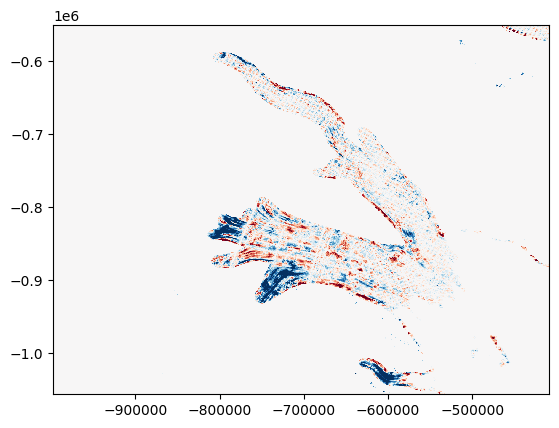

In [210]:
difference = (last_iterated_bed - INITIAL_BED)
plt.pcolormesh(xx, yy, difference, cmap='RdBu_r', 
                    vmax=300, vmin=-300, )

Loading realizations...
File for index 200 not found, skipping.
File for index 201 not found, skipping.
File for index 202 not found, skipping.
File for index 203 not found, skipping.
File for index 204 not found, skipping.
Loaded 70 realizations.


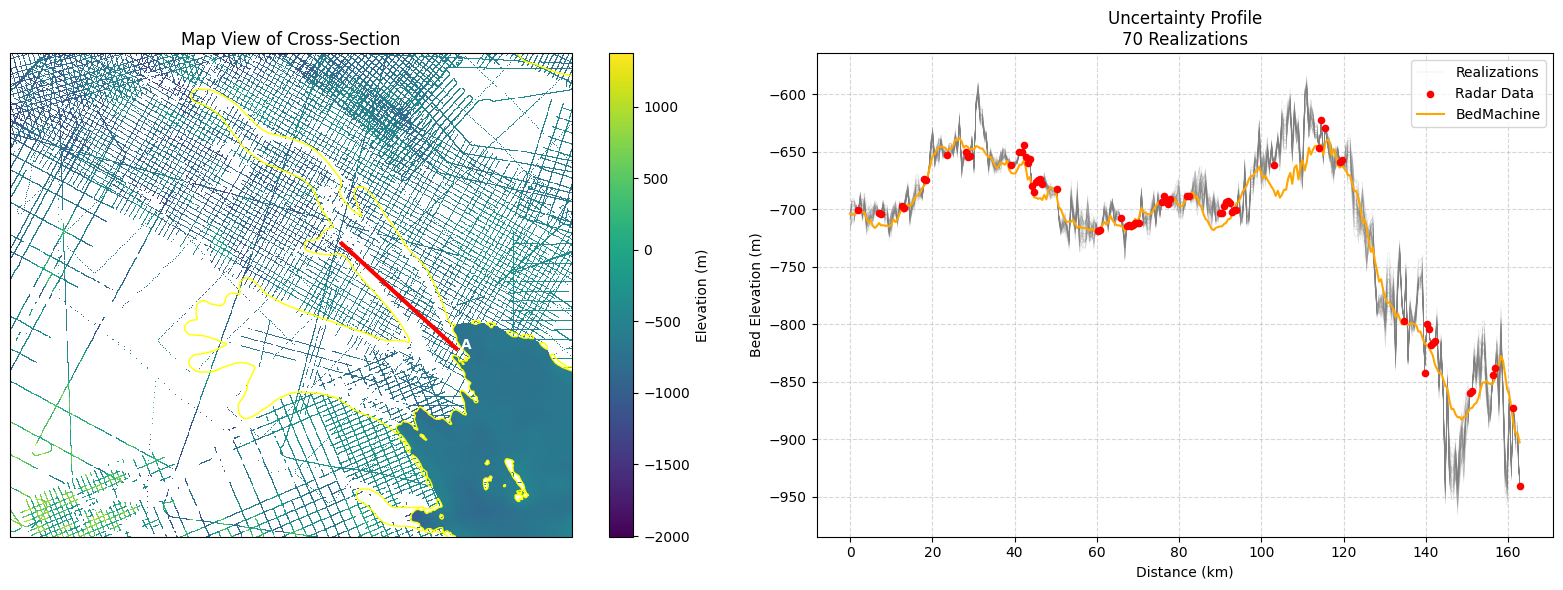

In [31]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

# --- 1. Load All Realizations ---
bed_to_plot = []
print("Loading realizations...")

# Assuming files are named like '200final_bed...', '201final_bed...'
for i in range(200, 275, 1):
    try:
        # Corrected filename logic to use 'i'
        bed = np.loadtxt(f"./SGS_realizations/{i}final_bed_largeCRF.txt")
        bed_to_plot.append(bed)
    except OSError:
        print(f"File for index {i} not found, skipping.")

print(f"Loaded {len(bed_to_plot)} realizations.")

# --- 2. Define Diagonal Slice Indices ---
# (Your original logic to find grid points)
x1, y1 = -530000, -860000  
x2, y2 = -650000, -750000   

dist = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
num_points = int(dist / 500) 

x_line = np.linspace(x1, x2, num_points)
y_line = np.linspace(y1, y2, num_points)

# Ensure xmin, ymin, resolution, cols, rows are defined in your environment!
col_indices = ((x_line - xmin) / resolution).astype(int)
row_indices = ((y_line - ymin) / resolution).astype(int)
col_indices = np.clip(col_indices, 0, cols - 1)
row_indices = np.clip(row_indices, 0, rows - 1)

# Extract Mask for Radar Points (Truth)
# Assuming 'bedmap_mask' and 'cond_bed' (or another reference bed) exist
mask_profile = bedmap_mask[row_indices, col_indices]
distance_vector = np.linspace(0, dist / 1000, num_points) # km

# Use one bed (or cond_bed) to find the Z-values for the Radar dots
ref_profile = cond_bed[row_indices, col_indices] # Using conditional bed for "Truth" dots
radar_dist = distance_vector[mask_profile == 1]
radar_bed = ref_profile[mask_profile == 1]

# --- 3. Plotting ---
fig = plt.figure(figsize=(16, 6))

# === Panel 1: Map View ===
projection = ccrs.SouthPolarStereo()
ax_map = fig.add_subplot(1, 2, 1, projection=projection)

mesh = ax_map.pcolormesh(xx, yy, cond_bed, cmap='viridis', shading='auto', transform=projection)
ax_map.contour(xx, yy, highvel_mask, levels=[0.5], colors='yellow', linewidths=1.0, transform=projection)
ax_map.plot([x1, x2], [y1, y2], color='red', linewidth=3, transform=projection)
ax_map.text(x1, y1, ' A', color='white', fontweight='bold', transform=projection)
ax_map.text(x2, y2, ' B', color='white', fontweight='bold', transform=projection)

ax_map.set_title("Map View of Cross-Section")
fig.colorbar(mesh, ax=ax_map, label='Elevation (m)')

# === Panel 2: Multiple Interpolations Profile ===
ax_prof = fig.add_subplot(1, 2, 2)

# Loop through all loaded beds and plot them
# We use label=None for the loop to avoid creating 75 legend entries
for i, bed in enumerate(bed_to_plot):
    profile = bed[row_indices, col_indices]
    
    # Plot only the first one with a label for the legend
    lbl = 'Realizations' if i == 0 else None
    ax_prof.plot(distance_vector, profile, color='gray', alpha=0.3, linewidth=0.2, label=lbl)

# Optional: Plot the Mean of all realizations in Black
mean_bed = np.mean(np.array(bed_to_plot), axis=0)
mean_profile = mean_bed[row_indices, col_indices]
#ax_prof.plot(distance_vector, mean_profile, color='purple', linewidth=1.0, linestyle='--', label='Mean Interpolation')

# Plot Radar Measurements (The "Hard" Data)

ax_prof.scatter(radar_dist, radar_bed, color='red', s=20, label='Radar Data', zorder=10)

#ax_prof.plot(radar_dist, sgs_bed[row_indices, col_indices], color ='lightblue', label='SGS')

bedmachine_bed = bedmap_surf - bedmachine_thickness
ax_prof.plot(radar_dist, bedmachine_bed[row_indices, col_indices], color ='orange', label='BedMachine')

ax_prof.set_title(f"Uncertainty Profile\n{len(bed_to_plot)} Realizations")
ax_prof.set_xlabel("Distance (km)")
ax_prof.set_ylabel("Bed Elevation (m)")
ax_prof.legend(loc='upper right')
ax_prof.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Loading realizations...
File for index 200 not found, skipping.
File for index 201 not found, skipping.
File for index 202 not found, skipping.
File for index 203 not found, skipping.
File for index 204 not found, skipping.
Loaded 70 realizations.


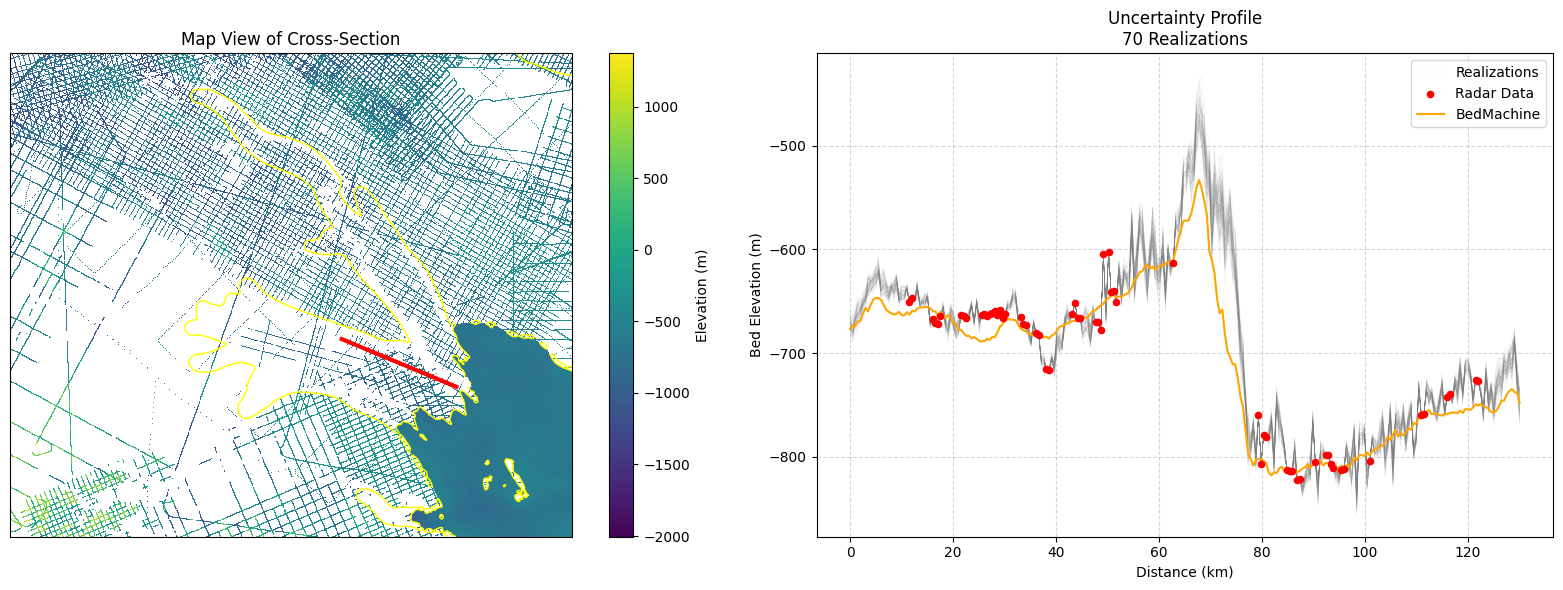

In [32]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np

# --- 1. Load All Realizations ---
bed_to_plot = []
print("Loading realizations...")

# Assuming files are named like '200final_bed...', '201final_bed...'
for i in range(200, 275, 1):
    try:
        # Corrected filename logic to use 'i'
        bed = np.loadtxt(f"./SGS_realizations/{i}final_bed_largeCRF.txt")
        bed_to_plot.append(bed)
    except OSError:
        print(f"File for index {i} not found, skipping.")

print(f"Loaded {len(bed_to_plot)} realizations.")

# --- 2. Define Diagonal Slice Indices ---
# (Your original logic to find grid points)
x1, y1 = -530000, -900000  
x2, y2 = -650000, -850000    

dist = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
num_points = int(dist / 500) 

x_line = np.linspace(x1, x2, num_points)
y_line = np.linspace(y1, y2, num_points)

# Ensure xmin, ymin, resolution, cols, rows are defined in your environment!
col_indices = ((x_line - xmin) / resolution).astype(int)
row_indices = ((y_line - ymin) / resolution).astype(int)
col_indices = np.clip(col_indices, 0, cols - 1)
row_indices = np.clip(row_indices, 0, rows - 1)

# Extract Mask for Radar Points (Truth)
# Assuming 'bedmap_mask' and 'cond_bed' (or another reference bed) exist
mask_profile = bedmap_mask[row_indices, col_indices]
distance_vector = np.linspace(0, dist / 1000, num_points) # km

# Use one bed (or cond_bed) to find the Z-values for the Radar dots
ref_profile = cond_bed[row_indices, col_indices] # Using conditional bed for "Truth" dots
radar_dist = distance_vector[mask_profile == 1]
radar_bed = ref_profile[mask_profile == 1]

# --- 3. Plotting ---
fig = plt.figure(figsize=(16, 6))

# === Panel 1: Map View ===
projection = ccrs.SouthPolarStereo()
ax_map = fig.add_subplot(1, 2, 1, projection=projection)

mesh = ax_map.pcolormesh(xx, yy, cond_bed, cmap='viridis', shading='auto', transform=projection)
ax_map.contour(xx, yy, highvel_mask, levels=[0.5], colors='yellow', linewidths=1.0, transform=projection)
ax_map.plot([x1, x2], [y1, y2], color='red', linewidth=3, transform=projection)
ax_map.text(x1, y1, ' A', color='white', fontweight='bold', transform=projection)
ax_map.text(x2, y2, ' B', color='white', fontweight='bold', transform=projection)

ax_map.set_title("Map View of Cross-Section")
fig.colorbar(mesh, ax=ax_map, label='Elevation (m)')

# === Panel 2: Multiple Interpolations Profile ===
ax_prof = fig.add_subplot(1, 2, 2)

# Loop through all loaded beds and plot them
# We use label=None for the loop to avoid creating 75 legend entries
for i, bed in enumerate(bed_to_plot):
    profile = bed[row_indices, col_indices]
    
    # Plot only the first one with a label for the legend
    lbl = 'Realizations' if i == 0 else None
    ax_prof.plot(distance_vector, profile, color='gray', alpha=0.2, linewidth=0.2, label=lbl)

# Optional: Plot the Mean of all realizations in Black
mean_bed = np.mean(np.array(bed_to_plot), axis=0)
mean_profile = mean_bed[row_indices, col_indices]
#ax_prof.plot(distance_vector, mean_profile, color='purple', linewidth=1.0, linestyle='--', label='Mean Interpolation')

# Plot Radar Measurements (The "Hard" Data)
ax_prof.scatter(radar_dist, radar_bed, color='red', s=20, label='Radar Data', zorder=10)

#ax_prof.plot(radar_dist, sgs_bed[row_indices, col_indices], color ='lightblue', label='SGS')

bedmachine_bed = bedmap_surf - bedmachine_thickness
ax_prof.plot(radar_dist, bedmachine_bed[row_indices, col_indices], color ='orange', label='BedMachine')

ax_prof.set_title(f"Uncertainty Profile\n{len(bed_to_plot)} Realizations")
ax_prof.set_xlabel("Distance (km)")
ax_prof.set_ylabel("Bed Elevation (m)")
ax_prof.legend(loc='upper right')
ax_prof.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

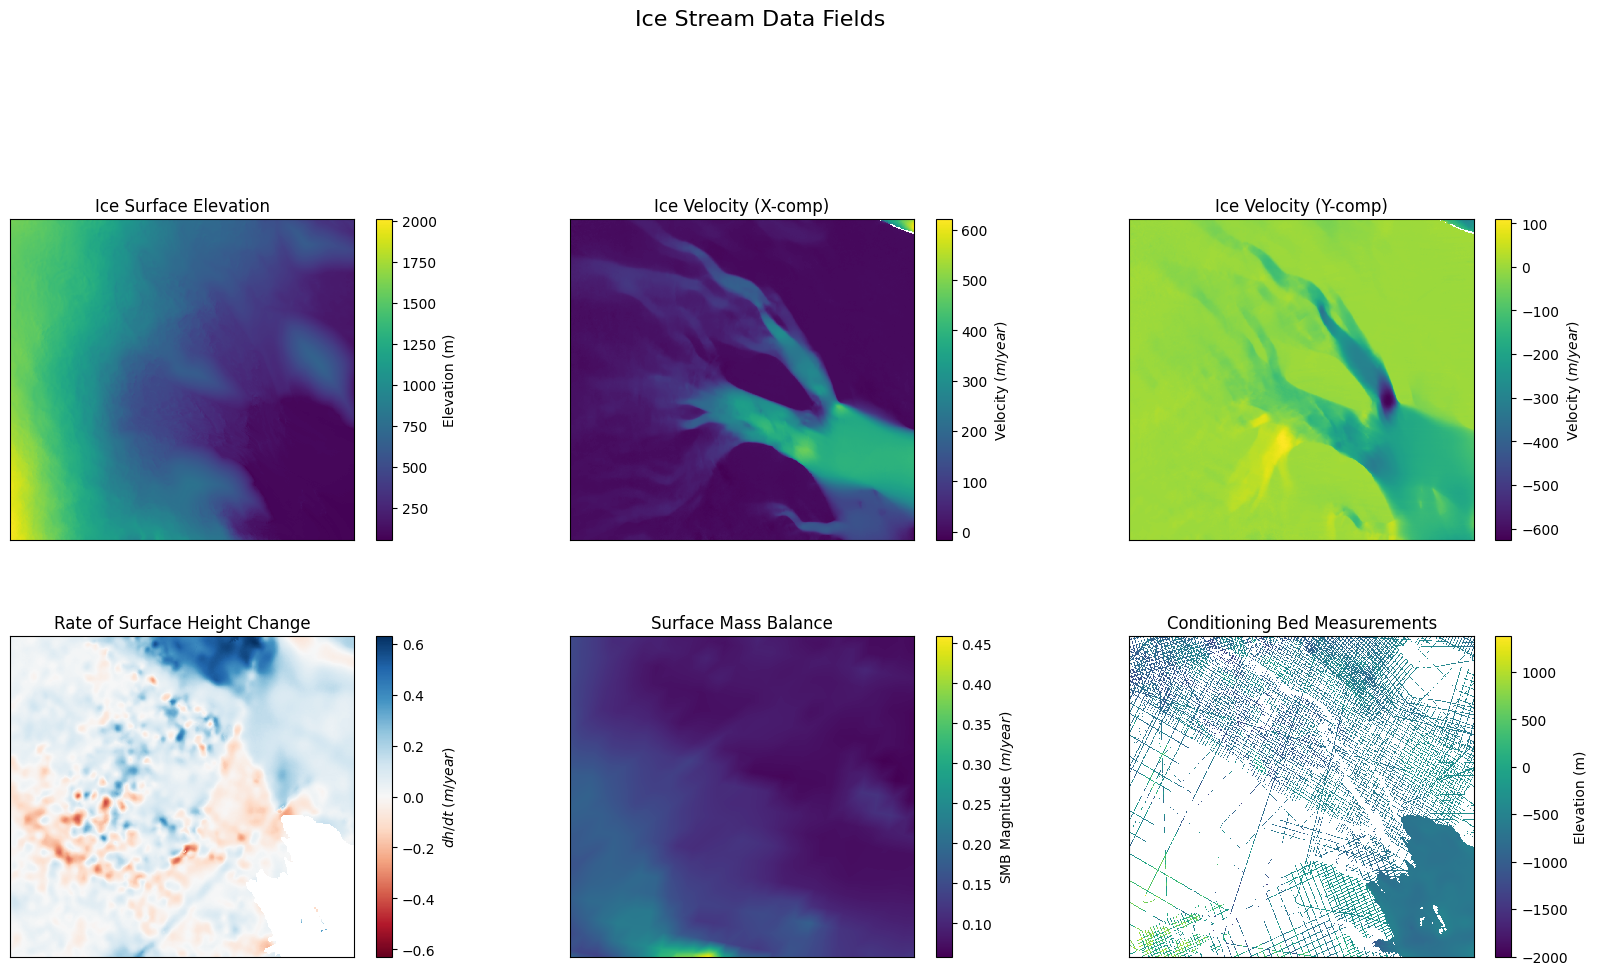

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import QuantileTransformer
import matplotlib.colors as colors

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(20, 15))
plt.subplots_adjust(hspace=0.3, wspace=0.3)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Helper function for plotting pcolormesh and colorbar
def plot_data(ax, data, title, label, cmap='viridis', norm=None):
    ims = ax.pcolormesh(xx, yy, data, cmap=cmap, norm=norm, shading='auto')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    cbar = fig.colorbar(ims, ax=ax, orientation='vertical')
    cbar.set_label(label)

# Helper function for plotting binary masks
def plot_mask(ax, mask, title, cmap='binary'):
    # Convert mask to float for pcolormesh and use cmap='binary'
    ims = ax.pcolormesh(xx, yy, mask.astype(float), cmap=cmap, shading='auto')
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])


# 2. Define the plotting order and parameters
plots_info = [
    # 1. Ice Surface Elevation (bedmap_surf)
    (bedmap_surf, "Ice Surface Elevation", "Elevation (m)"),
    # 2. Ice Velocity X (velx)
    (velx, "Ice Velocity (X-comp)", "Velocity ($m/year$)"),
    # 3. Ice Velocity Y (vely)
    (vely, "Ice Velocity (Y-comp)", "Velocity ($m/year$)"),
    # 4. Rate of Surface Height change (dhdt)
    (dhdt, "Rate of Surface Height Change", "$dh/dt$ ($m/year$)", 'RdBu', colors.CenteredNorm()),
    # 5. Surface Mass Balance (smb) - Used your original setup
    (smb, "Surface Mass Balance", "SMB Magnitude ($m/year$)"),
    # 6. Conditioning bed measurements (cond_bed)
    (cond_bed, "Conditioning Bed Measurements", "Elevation (m)"),

]

# 3. Execute the plotting loop
for i, (data, title, label, *rest) in enumerate(plots_info):
    ax = axes[i]
    cmap = rest[0] if rest and len(rest) > 0 else 'viridis'
    norm = rest[1] if rest and len(rest) > 1 else None

    # Check if it's the Grounded Ice Mask
    if title == "Grounded Ice Mask":
        plot_mask(ax, data, title)
    else:
        plot_data(ax, data, title, label, cmap=cmap, norm=norm)

# 4. Remove the unused subplot (the 8th index in the flattened 3x3 array)
if len(plots_info) < len(axes):
    for i in range(len(plots_info), len(axes)):
        fig.delaxes(axes[i])

# 5. Add a main title and save the figure
fig.suptitle("Ice Stream Data Fields", fontsize=16, y=1.02)

plt.savefig("multi_plot_figure.png", dpi=500, bbox_inches='tight')

plt.show()